**INSTALL LIBRARY & IMPORT**

In [2]:
!pip install nltk
!pip install Sastrawi
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

**BACA DATA**

In [4]:
data_path = 'youtube (6 desember).csv'
df = pd.read_csv(data_path)

In [5]:
df.sample(5)

,akun,tanggal posting,komen,like,balasan
49,@dadaniawan,4 hari yang lalu,mana ada pejabat takut sama rakyat... TAAI!!,225,10 balasan
275,@wigitkristianto3529,4 hari yang lalu,"Keren ya, besar banget ketidaktahudiriannya",20,NaN
551,@HarrySaputra-k7y,4 hari yang lalu,Masak sih Sumatra tdk masuk kategori bencana n...,11,NaN
79,@buenabandung4603,4 hari yang lalu,Dunia dan akhirat ya. Semoga cepat terbukti su...,216,6 balasan
631,@dinkoblt7896,1 hari yang lalu,datang bak pahlawan\nbencana dikontenkan\nkorb...,NaN,NaN


In [6]:
# Mengecek jumlah row & coloumn
print(f'shape: {df.shape}')

shape: (1044, 5)


**CLEANING DUPLICATE**

In [7]:
# Cek jumlah nilai duplikat di kolom 'akun'
duplicates = df['akun'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'akun': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'akun': 784

Contoh baris dengan nilai duplikat:
                       akun            tanggal posting  \
2           @dedrizaldi9583           4 hari yang lalu   
4                @Fawazil11           4 hari yang lalu   
5             @errysaefudin           4 hari yang lalu   
6                 @bhre_333           4 hari yang lalu   
7              @Ryuuto-1010           20 jam yang lalu   
8          @SamsungA8-d8t2p           4 hari yang lalu   
9          @fatihbarkan6159  4 hari yang lalu (diedit)   
10  @sendokgarpuchannel8234           4 hari yang lalu   
11        @montoyapablo2089           1 hari yang lalu   
12          @nenggeulis3902  4 hari yang lalu (diedit)   

                                                komen    like      balasan  
2   Kesini bukan dengar isi podcast tp baca komen2...  2,9 rb  110 balasan  
4   Intinya JANGAN PERNAH PERCAYA SAMA OMONGANYA P...  2,2 rb   35 balasan  
5   Memang keren Pak Menteri ini,,  tetap K

In [8]:
# Baca data
df = pd.read_csv('youtube (6 desember).csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['akun'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate youtobe.csv', index=False)

Sebelum: 1044 baris
Sesudah: 636 baris
Jumlah duplikat dihapus: 408


**BENERIN TANGGAL PUBLISH**

In [9]:
import pandas as pd
from datetime import datetime, timedelta
import pytz  # Library untuk menangani zona waktu
import numpy as np

# Membaca dataset
df = pd.read_csv('cleaning duplicate youtobe.csv')

# Fungsi untuk mengubah waktu relatif menjadi tanggal
def convert_to_date(time_str, reference_datetime):
    # Jika waktu adalah NaN, kembalikan 'Invalid Date'
    if pd.isna(time_str) or not isinstance(time_str, str):
        return 'Invalid Date'

    try:
        # Menghapus kata "Streamed" jika ada
        if 'Streamed' in time_str:
            time_str = time_str.replace('Streamed ', '')

        # Debug: Print nilai waktu yang diproses
        print(f"Processing time_str: '{time_str}'")

        if 'jam' in time_str:
            hours_ago = int(time_str.split()[0])
            date = reference_datetime - timedelta(hours=hours_ago)
        elif 'hari' in time_str:
            days_ago = int(time_str.split()[0])
            date = reference_datetime - timedelta(days=days_ago)
        else:
            date = np.nan

        # Debug: Print tanggal dan jam yang dihitung
        print(f"Calculated datetime: {date}")

    except Exception as e:
        print(f"Error converting '{time_str}': {e}")
        date = np.nan

    return date.strftime('%Y-%m-%d') if pd.notna(date) else 'Invalid Date'

# Tanggal dan waktu referensi (31 Juli 2024 pukul 23:00 WIB)
reference_datetime = datetime(2025, 12, 5, tzinfo=pytz.timezone('Asia/Jakarta'))

# Mengubah kolom "Waktu" menjadi format tanggal
df['tanggal posting'] = df['tanggal posting'].apply(lambda x: convert_to_date(x, reference_datetime))

# Mengganti 'Invalid Date' dengan tanggal default
default_date = '2025-12-01'
df['tanggal posting'] = df['tanggal posting'].replace('Invalid Date', default_date)

# Menyimpan hasil preprocessing ke file baru
df.to_csv('youtube_preprocessed_waktu.csv', index=False)

# Menampilkan beberapa hasil untuk verifikasi
print("Sample of preprocessed data:")
print(df.head())


Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '1 hari yang lalu'
Calculated datetime: 2025-12-04 00:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '20 jam yang lalu'
Calculated datetime: 2025-12-04 04:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '4 hari yang lalu (diedit)'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '4 hari yang lalu'
Calculated datetime: 2025-12-01 00:00:00+07:07
Processing time_str: '1 hari yang 

**BENERIN JUMLAH LIKE/VIEW**

In [10]:
import pandas as pd
import re

# Membaca dataset
df = pd.read_csv('youtube_preprocessed_waktu.csv')

# Fungsi untuk mengubah format tampilan menjadi angka
def convert_like(like_str):
    # Jika data adalah NaN atau bukan string, kembalikan 0
    if pd.isna(like_str) or not isinstance(like_str, str):
        return 0

    # Debug: Print nilai yang diproses
    print(f"Processing like_str: '{like_str}'")

    try:
       # Langkah 1: Normalisasi — hapus "like", ubah ke lowercase, dan ganti koma jadi titik

        like_str = like_str.replace(',', '.')  # ← PINDAH KE SINI!

        # Menghapus kata 'views' dan spasi ekstra
        like_str = like_str.lower().replace(' like', '').strip()

        # Cek apakah ada format 'K' untuk ribuan
        if 'rb' in like_str:
            number = float(like_str.replace('rb', '').strip()) * 1000
        # Cek apakah ada format 'M' untuk juta
        elif 'jt' in like_str:
            number = float(like_str.replace('jt', '').strip()) * 1000000
        # Jika angka biasa
        else:
            # Mengganti koma dengan titik jika ada
            like_str = like_str.replace(',', '.')
            number = float(like_str.strip())

        return int(number)
    except Exception as e:
        # Menangani error konversi dan mencetak error
        print(f"Error converting '{like_str}': {e}")
        return 0

# Mengubah kolom "like" menjadi angka
df['like'] = df['like'].apply(convert_like)


# Menyimpan hasil preprocessing ke file baru
df.to_csv('youtube_preprocessed_2.csv', index=False)

# Menampilkan beberapa hasil untuk verifikasi
print("Sample of preprocessed data:")
print(df.head())

Processing like_str: '5,8 rb'
Processing like_str: '6,1 rb'
Processing like_str: '2,9 rb'
Processing like_str: '27'
Processing like_str: '2,2 rb'
Processing like_str: '2,2 rb'
Processing like_str: '2,8 rb'
Processing like_str: '19'
Processing like_str: '973'
Processing like_str: '1,2 rb'
Processing like_str: '1,7 rb'
Processing like_str: '7'
Processing like_str: '681'
Processing like_str: '992'
Processing like_str: '384'
Processing like_str: '5'
Processing like_str: '1 rb'
Processing like_str: '731'
Processing like_str: '178'
Processing like_str: '1'
Processing like_str: '626'
Processing like_str: '199'
Processing like_str: '284'
Processing like_str: '166'
Processing like_str: '448'
Processing like_str: '245'
Processing like_str: '237'
Processing like_str: '369'
Processing like_str: '175'
Processing like_str: '1'
Processing like_str: '225'
Processing like_str: '218'
Processing like_str: '182'
Processing like_str: '184'
Processing like_str: '255'
Processing like_str: '301'
Processing li

**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [11]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
                     akun tanggal posting  \
0               @SFayriza      2025-12-01   
1  @rohmatwargosusilo6058      2025-12-01   
2         @dedrizaldi9583      2025-12-01   
3     @yulinestiyarum5489      2025-12-04   
4              @Fawazil11      2025-12-01   

                                               komen  like      balasan  \
0    UNDANG HORISON FORD KOH BUAT INFORMASI DUA SISI  5800  471 balasan   
1         berapa yg muak lihat dan dengar omongannya  6100  207 balasan   
2  Kesini bukan dengar isi podcast tp baca komen2...  2900  110 balasan   
3  Rakyat tidak lagi percaya omongan politisi yan...    27          NaN   
4  Intinya JANGAN PERNAH PERCAYA SAMA OMONGANYA P...  2200   35 balasan   

                                       cleaned_komen  
0    undang horison ford koh buat informasi dua sisi  
1         berapa yg muak lihat dan dengar omongannya  
2  kesini bukan dengar isi podcast tp baca komen ...  
3  rakyat tidak lagi percaya om

**MENGHAPUS STOPWORDS**

In [12]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Data Setelah Penghapusan Stop Words:
                     akun tanggal posting  \
0               @SFayriza      2025-12-01   
1  @rohmatwargosusilo6058      2025-12-01   
2         @dedrizaldi9583      2025-12-01   
3     @yulinestiyarum5489      2025-12-04   
4              @Fawazil11      2025-12-01   

                                               komen  like      balasan  \
0    UNDANG HORISON FORD KOH BUAT INFORMASI DUA SISI  5800  471 balasan   
1         berapa yg muak lihat dan dengar omongannya  6100  207 balasan   
2  Kesini bukan dengar isi podcast tp baca komen2...  2900  110 balasan   
3  Rakyat tidak lagi percaya omongan politisi yan...    27          NaN   
4  Intinya JANGAN PERNAH PERCAYA SAMA OMONGANYA P...  2200   35 balasan   

                                       cleaned_komen  
0             undang horison ford koh informasi sisi  
1                    yg muak lihat dengar omongannya  
2  kesini dengar isi podcast tp baca komen netize...  
3  rakyat percaya om

**STEMMING DATA**

In [13]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
                     akun tanggal posting  \
0               @SFayriza      2025-12-01   
1  @rohmatwargosusilo6058      2025-12-01   
2         @dedrizaldi9583      2025-12-01   
3     @yulinestiyarum5489      2025-12-04   
4              @Fawazil11      2025-12-01   

                                               komen  like      balasan  \
0    UNDANG HORISON FORD KOH BUAT INFORMASI DUA SISI  5800  471 balasan   
1         berapa yg muak lihat dan dengar omongannya  6100  207 balasan   
2  Kesini bukan dengar isi podcast tp baca komen2...  2900  110 balasan   
3  Rakyat tidak lagi percaya omongan politisi yan...    27          NaN   
4  Intinya JANGAN PERNAH PERCAYA SAMA OMONGANYA P...  2200   35 balasan   

                                       cleaned_komen  \
0             undang horison ford koh informasi sisi   
1                    yg muak lihat dengar omongannya   
2  kesini dengar isi podcast tp baca komen netize...   
3  rakyat percaya omongan poli

**TOKENIZATION**

In [14]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean.csv', index=False)


Data Setelah Tokenisasi:
                     akun tanggal posting  \
0               @SFayriza      2025-12-01   
1  @rohmatwargosusilo6058      2025-12-01   
2         @dedrizaldi9583      2025-12-01   
3     @yulinestiyarum5489      2025-12-04   
4              @Fawazil11      2025-12-01   

                                               komen  like      balasan  \
0    UNDANG HORISON FORD KOH BUAT INFORMASI DUA SISI  5800  471 balasan   
1         berapa yg muak lihat dan dengar omongannya  6100  207 balasan   
2  Kesini bukan dengar isi podcast tp baca komen2...  2900  110 balasan   
3  Rakyat tidak lagi percaya omongan politisi yan...    27          NaN   
4  Intinya JANGAN PERNAH PERCAYA SAMA OMONGANYA P...  2200   35 balasan   

                                       cleaned_komen  \
0             undang horison ford koh informasi sisi   
1                    yg muak lihat dengar omongannya   
2  kesini dengar isi podcast tp baca komen netize...   
3  rakyat percaya omongan po

**BUAT VISUALISASI WORLDCLOUD**

In [15]:
from wordcloud import STOPWORDS

# Tambahkan kata khusus Indonesia yang mungkin tidak ada di daftar bawaan
stop_words = set(STOPWORDS)
stop_words.update(['yg', 'nya', 'dgn', 'ya', 'trs', 'jg', 'kalo', 'gw', 'lu', 'gue', 'lo', 'nih', 'mah', 'sih', 'krn', 'karena'])

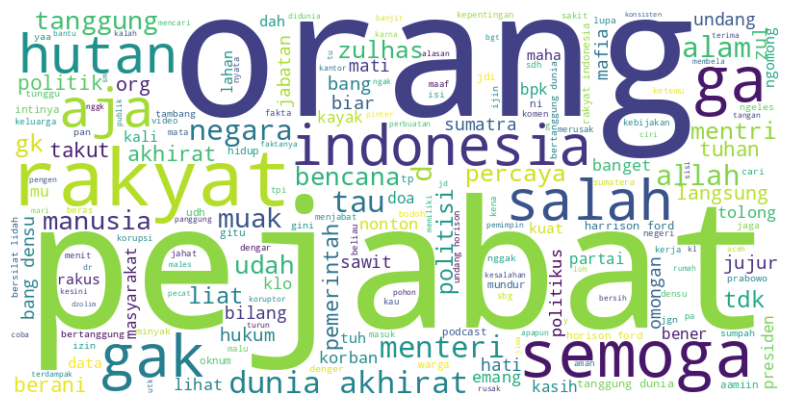

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data dari file CSV
df = pd.read_csv('processed_clean.csv')  # Ganti 'path_to_your_file.csv' dengan jalur file data Anda

# Gabungkan semua teks dalam kolom 'cleaned_komen' menjadi satu string besar
text = " ".join(judul for judul in df['cleaned_komen'].dropna())  # Pastikan tidak ada nilai NaN



# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

**VISUALISASI KATA KUNCI TERBANYAK (WORDCLOUD)**

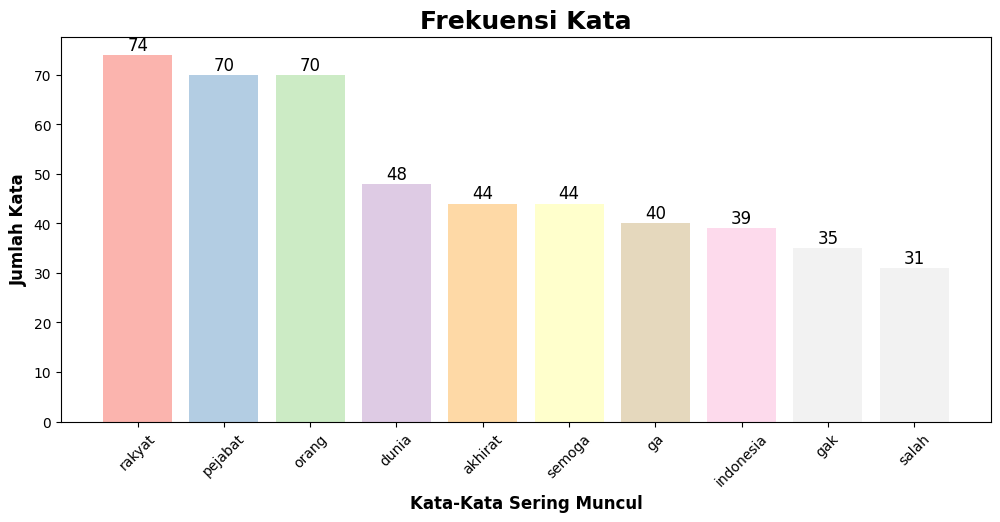

In [17]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = " ".join(judul for judul in df['cleaned_komen'].dropna())


tokens = [word for word in text.split() if word not in stop_words]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel1(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

**LABELING DATA (POSITIF, NEGATIF, NETRAL) LEXICON BASED**

In [18]:
# Unduh kamus leksikon positif dan negatif dari GITHUB
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep='\t', header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep='\t', header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count

        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"

In [19]:
# Tentukan sentimen dan skor untuk setiap ulasan
df[['Score', 'label']] = df['stemmed_komen'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
df.head(10)

,akun,tanggal posting,komen,like,balasan,cleaned_komen,stemmed_komen,tokens,Score,label
0,@SFayriza,2025-12-01,UNDANG HORISON FORD KOH BUAT INFORMASI DUA SISI,5800,471 balasan,undang horison ford koh informasi sisi,undang horison ford koh informasi sisi,"['undang', 'horison', 'ford', 'koh', 'informas...",1,Positif
1,@rohmatwargosusilo6058,2025-12-01,berapa yg muak lihat dan dengar omongannya,6100,207 balasan,yg muak lihat dengar omongannya,yg muak lihat dengar omong,"['yg', 'muak', 'lihat', 'dengar', 'omong']",0,Netral
2,@dedrizaldi9583,2025-12-01,Kesini bukan dengar isi podcast tp baca komen2...,2900,110 balasan,kesini dengar isi podcast tp baca komen netize...,kesini dengar isi podcast tp baca komen netize...,"['kesini', 'dengar', 'isi', 'podcast', 'tp', '...",1,Positif
3,@yulinestiyarum5489,2025-12-04,Rakyat tidak lagi percaya omongan politisi yan...,27,NaN,rakyat percaya omongan politisi memperkaya par...,rakyat percaya omong politis kaya partai dzolim,"['rakyat', 'percaya', 'omong', 'politis', 'kay...",0,Netral
4,@Fawazil11,2025-12-01,Intinya JANGAN PERNAH PERCAYA SAMA OMONGANYA P...,2200,35 balasan,intinya percaya omonganya politisiingat yaa om...,inti percaya omonganya politisiingat yaa omong...,"['inti', 'percaya', 'omonganya', 'politisiinga...",1,Positif
5,@errysaefudin,2025-12-01,"Memang keren Pak Menteri ini,, tetap KONSISTE...",2200,67 balasan,keren menteri konsisten gak nyambungnya,keren menteri konsisten gak nyambungnya,"['keren', 'menteri', 'konsisten', 'gak', 'nyam...",0,Netral
6,@bhre_333,2025-12-01,"Baik pak Zul, anda sudah bersumpah d hadapan A...",2800,136 balasan,zul bersumpah d hadapan alam semesta yg bertan...,zul sumpah d hadap alam semesta yg tanggung ap...,"['zul', 'sumpah', 'd', 'hadap', 'alam', 'semes...",-2,Negatif
7,@Ryuuto-1010,2025-12-04,"""Ga bisa masuk ya sudah"" wkwkwwkwkwkwk sudah T...",19,NaN,ga masuk ya wkwkwwkwkwkwk beralasan,ga masuk ya wkwkwwkwkwkwk alas,"['ga', 'masuk', 'ya', 'wkwkwwkwkwkwk', 'alas']",0,Netral
8,@SamsungA8-d8t2p,2025-12-01,"Pembohongggg, kamu pembohonggggg",973,10 balasan,pembohongggg pembohonggggg,pembohongggg pembohonggggg,"['pembohongggg', 'pembohonggggg']",0,Netral
9,@fatihbarkan6159,2025-12-01,"Bang densu, izin masukan, alangkah baiknya ban...",1200,73 balasan,bang densu izin masukan alangkah baiknya bang ...,bang densu izin masuk alangkah baik bang densu...,"['bang', 'densu', 'izin', 'masuk', 'alangkah',...",-3,Negatif


**VISUALISASI JUMLAH SENTIMEN PUBLIK **



/tmp/ipython-input-664524484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")


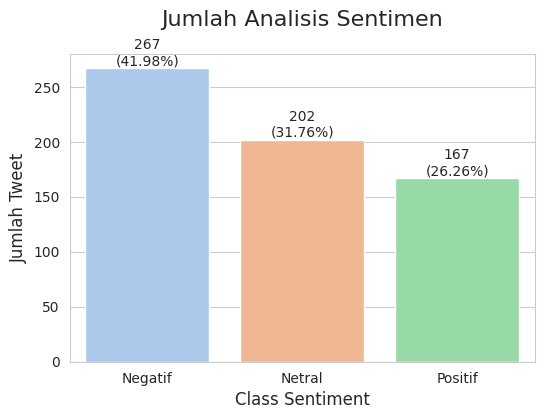

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['label'].value_counts()
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")
plt.title("Jumlah Analisis Sentimen", fontsize=16, pad=20)
plt.xlabel("Class Sentiment", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)

total = len(df['label'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('labeling_data.csv', index=False)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   akun             636 non-null    object
 1   tanggal posting  636 non-null    object
 2   komen            636 non-null    object
 3   like             636 non-null    int64 
 4   balasan          159 non-null    object
 5   cleaned_komen    635 non-null    object
 6   stemmed_komen    635 non-null    object
 7   tokens           636 non-null    object
 8   Score            636 non-null    int64 
 9   label            636 non-null    object
dtypes: int64(2), object(8)
memory usage: 49.8+ KB


In [22]:
label_count = df['label'].value_counts()
label_count

,count
label,
Negatif,267
Netral,202
Positif,167


**WORLDCLOUD LABEL POSITIF**

In [25]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Daftar stopwords tambahan yang ingin dikecualikan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue',
    'kak', 'tan', 'ajar', 'dan', 'di', 'ke', 'sih',
    'dari', 'adalah', 'yang', 'untuk', 'dengan', 'pada', 'ini'
])

# Fungsi untuk membuat word cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        colormap='tab20'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = df[df['label'] == 'Netral']['stemmed_komen'].str.cat(sep=' ')
sentimen_Negative = df[df['label'] == 'Negatif']['stemmed_komen'].str.cat(sep=' ')
sentimen_Positive = df[df['label'] == 'Positif']['stemmed_komen'].str.cat(sep=' ')

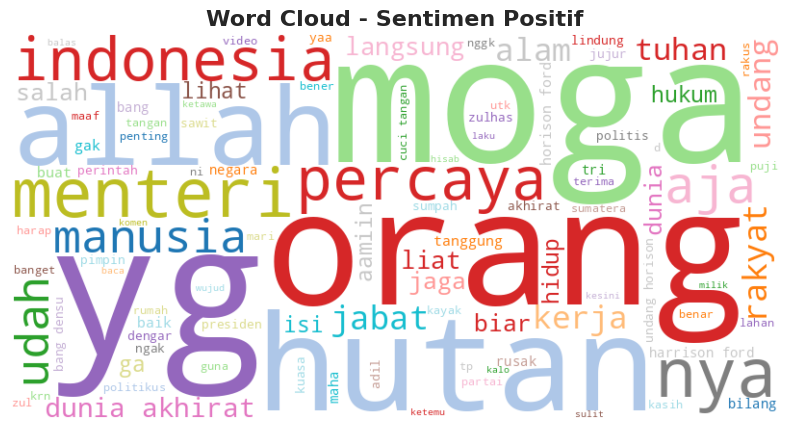

In [26]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Positive, "Word Cloud - Sentimen Positif")

**WORLDCLOUD LABEL NEGATIF**

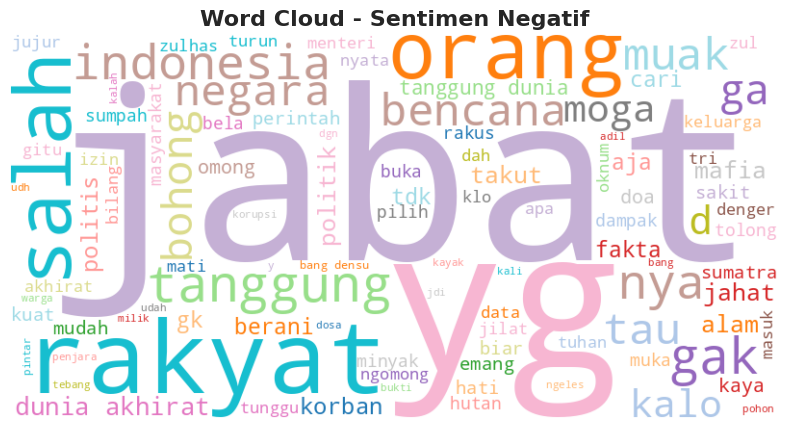

In [27]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Negative, "Word Cloud - Sentimen Negatif")

**WORLDCLOUD LABEL NETRAL**

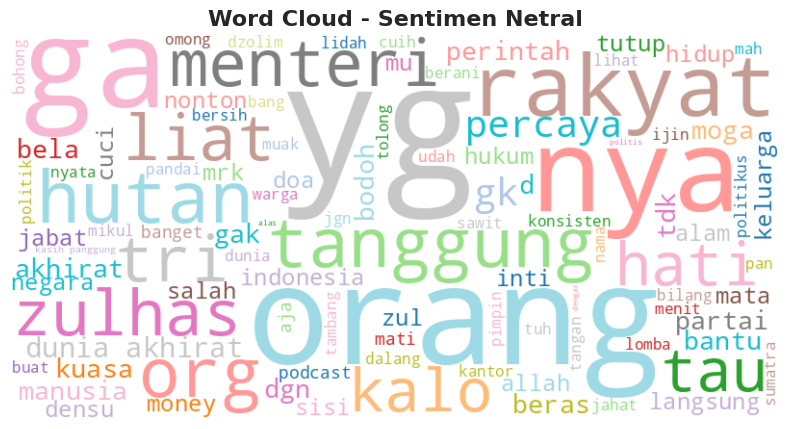

In [28]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Neutral, "Word Cloud - Sentimen Netral")

**FEATURE EXTRACTION**

In [31]:
df_list = df['stemmed_komen'].tolist()
print(df_list)

['undang horison ford koh informasi sisi', 'yg muak lihat dengar omong', 'kesini dengar isi podcast tp baca komen netizen indonesia', 'rakyat percaya omong politis kaya partai dzolim', 'inti percaya omonganya politisiingat yaa omonganya politis', 'keren menteri konsisten gak nyambungnya', 'zul sumpah d hadap alam semesta yg tanggung apa yg deal', 'ga masuk ya wkwkwwkwkwkwk alas', 'pembohongggg pembohonggggg', 'bang densu izin masuk alangkah baik bang densu siap data temu politikus alih status hutan milik alih lahan oligarki belakang politis licin siap abrek data fakta wawancara politis politis pintar pilih bang densu tau kapasitas bang densu tajam wartawan senior data pintar kelit alih isu', 'menteri kontribusi rakyat', 'indonesia tdk blajar dt silap dosa yg', 'cuihhh munafikpadahal slh dalang wwkkwk', 'manusia zulhas bahlil luhut mulyono raja juli periksa damkar', 'ges jabat patah kaki beri tongkat kau berterimakasih', 'iyo iyo alah mah cukuik haahah lawak', 'pintar kali bpa rangkai b

In [34]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Isi nilai NaN dengan string kosong
df['stemmed_komen'] = df['stemmed_komen'].fillna('')

# Buat list dari kolom 'steming_data'
df_list = df['stemmed_komen'].tolist()

# Buat objek TfidfVectorizer
df_tfidf = TfidfVectorizer()

# Lakukan transformasi fitur
X = df_tfidf.fit_transform(df_list)

print('Feature Extraction Selesai!!!')
print('===== Bentuk Transformasi Feature Extraction =====')
print(X.shape)

# Dapatkan nama fitur (kata-kata unik)
feature_names = df_tfidf.get_feature_names_out()

# Hitung total skor TF-IDF untuk setiap term (kata)
tfidf_sums = X.sum(axis=0)

# Buat DataFrame untuk menampilkan hasil
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_sum': tfidf_sums.tolist()[0]
})

# Urutkan berdasarkan skor TF-IDF terbesar
tfidf_df = tfidf_df.sort_values('tfidf_sum', ascending=False)

print("\n==== Top 20 Terms by Total TF-IDF Score ====")
print(tfidf_df.head(20))

print("\n==== IDF Values ====")
idf_values = df_tfidf.idf_
idf_df = pd.DataFrame({
    'Term': feature_names,
    'IDF': idf_values
})
print(idf_df.head(20))

print("\n==== TF-IDF values for the first 5 documents ====")
for i in range(min(5, len(df_list))):
    first_document_tfidf = pd.DataFrame(
        X[i].T.todense(),
        index=feature_names,
        columns=["TF-IDF"]
    )
    print(f"\nDocument {i+1} TF-IDF Values:")
    print(first_document_tfidf.sort_values("TF-IDF", ascending=False).head(10))

Feature Extraction Selesai!!!
===== Bentuk Transformasi Feature Extraction =====
(636, 2056)

==== Top 20 Terms by Total TF-IDF Score ====
           term  tfidf_sum
2044         yg  17.800346
719       jabat  15.946240
1374      orang  13.998565
1575     rakyat  13.810494
2031         ya  11.616764
1834   tanggung  10.722831
469       dunia  10.555518
1327        nya  10.274825
33      akhirat  10.135827
1177       moga   9.855646
526          ga   9.627342
1197       muak   8.863895
1634      salah   8.528562
1464    percaya   8.043786
533         gak   7.900886
680   indonesia   7.787518
1144    menteri   7.064143
22          aja   7.032831
651       hutan   6.923477
59        allah   6.728719

==== IDF Values ====
             Term       IDF
0          aamiin  5.377328
1        aamiinnn  6.763622
2          aamijn  6.763622
3            abai  6.763622
4            abdi  6.763622
5            abis  6.763622
6           abrek  6.763622
7           acara  6.763622
8            aceh  5

In [36]:
y = df['label']
print(y)

0      Positif
1       Netral
2      Positif
3       Netral
4      Positif
        ...   
631    Positif
632    Positif
633    Negatif
634    Negatif
635    Negatif
Name: label, Length: 636, dtype: object


In [37]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5220 stored elements and shape (636, 2056)>
  Coords	Values
  (0, 1978)	0.3353951306338293
  (0, 635)	0.37601894811088293
  (0, 520)	0.3353951306338293
  (0, 912)	0.45120980717087567
  (0, 684)	0.5027304526740889
  (0, 1747)	0.421072161538548
  (1, 2044)	0.2907241459463503
  (1, 1197)	0.4370545396356393
  (1, 1028)	0.49248720432848525
  (1, 401)	0.5105470409912836
  (1, 1361)	0.47038375062857124
  (2, 401)	0.32147790488607314
  (2, 879)	0.35333923024153735
  (2, 705)	0.3155331979114197
  (2, 1497)	0.32804947356394215
  (2, 1925)	0.32804947356394215
  (2, 129)	0.35333923024153735
  (2, 913)	0.34372451098071927
  (2, 1250)	0.3965723548374171
  (2, 680)	0.23821093205203994
  (3, 1361)	0.3788597277828226
  (3, 1575)	0.2631101754876171
  (3, 1464)	0.34475762412047717
  (3, 1508)	0.36887403064433166
  (3, 824)	0.39666244405569423
  :	:
  (633, 1374)	0.09538939656052103
  (633, 560)	0.1542721238193422
  (633, 744)	0.157726916732096

**KLASIFIKASI MODEL MACHINE LEARNING**

In [38]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

Jumlah data training (X_train): 508
Jumlah data testing (X_test): 128


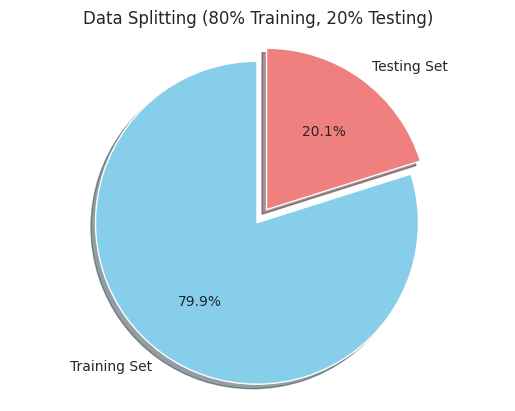

In [39]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Jumlah data training (X_train):", X_train.shape[0])
print("Jumlah data testing (X_test):", X_test.shape[0])

# Visualize the data split
import matplotlib.pyplot as plt

train_size = X_train.shape[0]
test_size = X_test.shape[0]
total_size = train_size + test_size

labels = ['Training Set', 'Testing Set']
sizes = [train_size, test_size]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data Splitting (80% Training, 20% Testing)')
plt.show()


Training and evaluating: Logistic Regression
Accuracy: 0.5781
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.64      0.71      0.67        59
      Netral       0.40      0.46      0.43        37
     Positif       0.75      0.47      0.58        32

    accuracy                           0.58       128
   macro avg       0.60      0.55      0.56       128
weighted avg       0.60      0.58      0.58       128

Confusion Matrix:
[[42 16  1]
 [16 17  4]
 [ 8  9 15]]


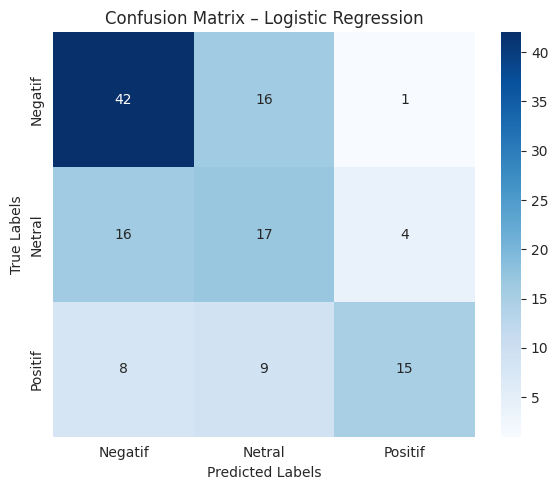


Training and evaluating: Decision Tree
Accuracy: 0.6172
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.83      0.64      0.72        59
      Netral       0.44      0.65      0.52        37
     Positif       0.63      0.53      0.58        32

    accuracy                           0.62       128
   macro avg       0.63      0.61      0.61       128
weighted avg       0.66      0.62      0.63       128

Confusion Matrix:
[[38 19  2]
 [ 5 24  8]
 [ 3 12 17]]


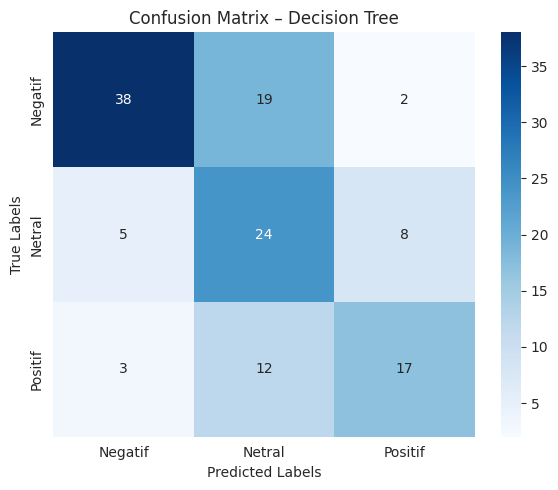


Training and evaluating: Random Forest
Accuracy: 0.6016
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.78      0.59      0.67        59
      Netral       0.42      0.76      0.54        37
     Positif       0.88      0.44      0.58        32

    accuracy                           0.60       128
   macro avg       0.69      0.60      0.60       128
weighted avg       0.70      0.60      0.61       128

Confusion Matrix:
[[35 24  0]
 [ 7 28  2]
 [ 3 15 14]]


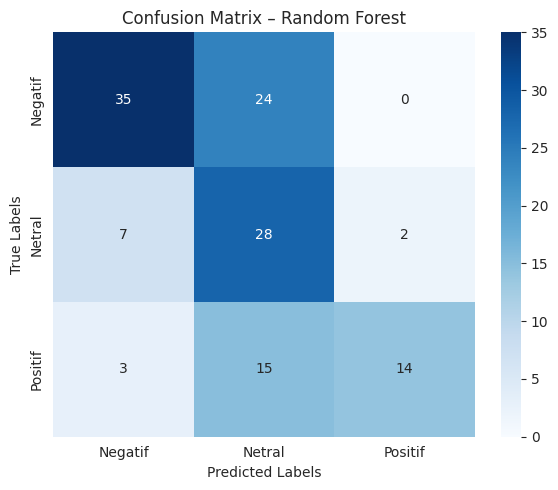


Training and evaluating: Support Vector Machine
Accuracy: 0.5547
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.57      0.88      0.69        59
      Netral       0.39      0.30      0.34        37
     Positif       0.89      0.25      0.39        32

    accuracy                           0.55       128
   macro avg       0.62      0.48      0.47       128
weighted avg       0.60      0.55      0.51       128

Confusion Matrix:
[[52  7  0]
 [25 11  1]
 [14 10  8]]


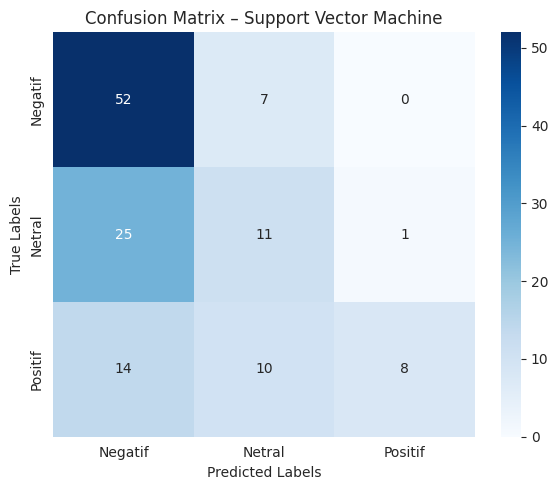


Training and evaluating: K-Nearest Neighbors
Accuracy: 0.5156
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.62      0.56      0.59        59
      Netral       0.38      0.65      0.48        37
     Positif       0.75      0.28      0.41        32

    accuracy                           0.52       128
   macro avg       0.58      0.50      0.49       128
weighted avg       0.58      0.52      0.51       128

Confusion Matrix:
[[33 25  1]
 [11 24  2]
 [ 9 14  9]]


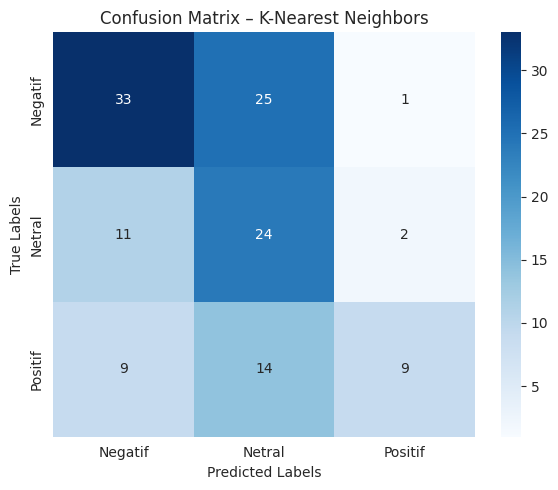


Training and evaluating: Naive Bayes
Accuracy: 0.5703
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.56      0.92      0.70        59
      Netral       0.42      0.22      0.29        37
     Positif       0.85      0.34      0.49        32

    accuracy                           0.57       128
   macro avg       0.61      0.49      0.49       128
weighted avg       0.59      0.57      0.53       128

Confusion Matrix:
[[54  5  0]
 [27  8  2]
 [15  6 11]]


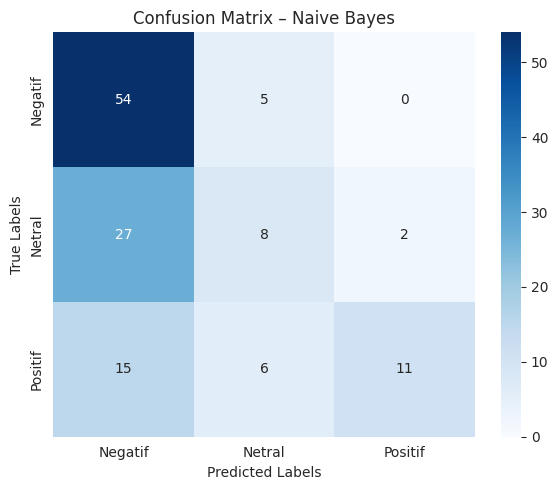

In [44]:
# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training and evaluating: {name}")
    print(f"{'='*50}")

    # Train & predict
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Simpan ke results
    results[name] = {
        'accuracy': accuracy,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    # Tampilkan hasil untuk model ini
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Classification Report:\n{results[name]['classification_report']}")
    print(f"Confusion Matrix:\n{results[name]['confusion_matrix']}")

    # Plot confusion matrix untuk model ini
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        results[name]['confusion_matrix'],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=clf.classes_,
        yticklabels=clf.classes_
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

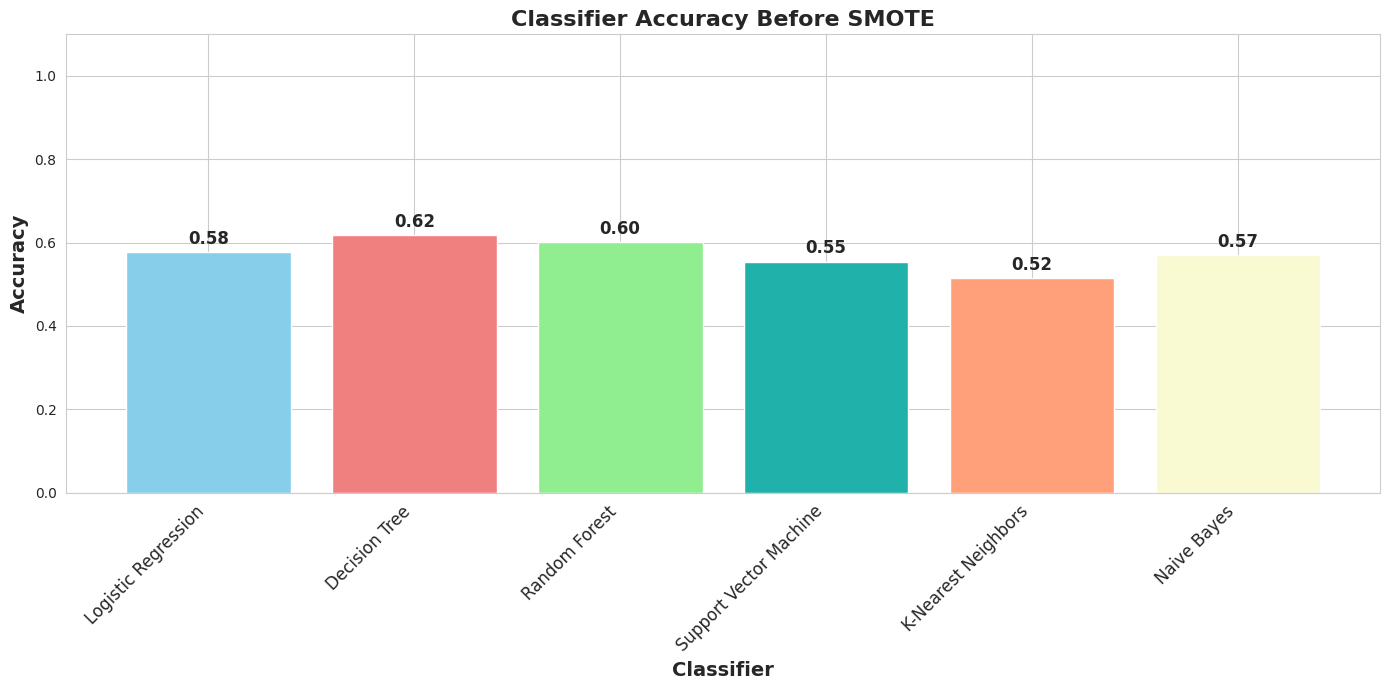

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'results' dictionary is defined from previous code
classifiers = list(results.keys())
accuracy_before = [results[name]['accuracy'] for name in classifiers]

# Improved Plotting
plt.figure(figsize=(14, 7))  # Slightly larger figure for better readability
bars = plt.bar(classifiers, accuracy_before, color=['skyblue', 'lightcoral', 'lightgreen', 'lightseagreen', 'lightsalmon', 'lightgoldenrodyellow'])
plt.xlabel("Classifier", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.title("Classifier Accuracy Before SMOTE", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.xticks(rotation=45, ha='right', fontsize=12)  # Adjust font size and rotation

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracy_before):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()  # Ensure labels are not cut off
plt.show()